# Introduction to MLP-Based Car Price and Brand/Model Prediction

In this notebook, we will apply a Multilayer Perceptron (MLP) pipeline to solve two related tasks on the cleaned automotive dataset:

1. Regression task:
    - target: `sellingprice`
    - features: numeric and encoded categorical attributes (year, odometer, mmr, condition_normalized, body, make/model embeddings, etc.)
    - output: predicted car price

2. Classification task:
    - targets: `make` (brand) and `model`
    - same feature set with appropriate categorical encoding
    - output: class probabilities for each brand/model

This structured approach allows us to evaluate how well a shared MLP architecture captures both continuous pricing behavior and discrete brand/model identity from the same input features.

In [2]:
import pandas as pd 
import numpy as np 
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('dataset.csv')

# Display the first few rows of the dataset
print(df.head())

print(df.info())

  year\tmake\tmodel\ttrim\tbody\ttransmission\tvin\tstate\tcondition\todometer\tcolor\tinterior\tseller\tmmr\tsellingprice\tsaledate
0  2015\tKia\tSorento\tLX\tSUV\tautomatic\t5xyktc...                                                                                
1  2015\tKia\tSorento\tLX\tSUV\tautomatic\t5xyktc...                                                                                
2  2014\tBMW\t3 Series\t328i SULEV\tSedan\tautoma...                                                                                
3  2015\tVolvo\tS60\tT5\tSedan\tautomatic\tyv1612...                                                                                
4  2014\tBMW\t6 Series Gran Coupe\t650i\tSedan\ta...                                                                                
<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 1 columns):
 #   Column                                                                                            

# Data Cleaning

Data cleaning is a crucial early step in the pipeline.  
It ensures the dataset is reliable and consistent before feature engineering or model training.

- Split raw combined string rows into separate logically named columns (`year`, `make`, `model`, etc.).
- Convert types:
    - categorical text to uppercase (standardization)
    - numeric fields (`year`, `odometer`, `mmr`, `sellingprice`, `condition`) to numeric type
    - date strings (`saledate`) to proper `datetime`
- Normalize continuous variables (`condition`) with MinMax scaling so ranges align for ML and comparison.
- Handle missing and invalid values:
    - fill missing or invalid condition with "Unknown" after normalization
    - drop rows where core numeric labels (`mmr`, `sellingprice`, `year`) are missing

Goal:
- eliminate format inconsistencies
- enforce accurate types for calculations
- reduce noise from missing/invalid data
- make downstream analysis/ML resilient and interpretable.

In [3]:
from sklearn.preprocessing import MinMaxScaler

# Create new features based on existing ones, and drop original column
split_columns = df['year\tmake\tmodel\ttrim\tbody\ttransmission\tvin\tstate\tcondition\todometer\tcolor\tinterior\tseller\tmmr\tsellingprice\tsaledate'].str.split('\t', expand=True)
split_columns.columns = ['year','make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate']
df_clean = pd.concat([df, split_columns], axis=1)
df_clean.drop(df_clean.columns[0], axis=1, inplace=True)

# Convert all string columns to uppercase (robust column-wise approach)
df_upper_case = df_clean.copy()
for col in df_upper_case.select_dtypes(include='object').columns:
    df_upper_case[col] = df_upper_case[col].str.upper()

#Convert saledate to datetime format (handle mixed timezones)
df_upper_case['saledate'] = pd.to_datetime(df_upper_case['saledate'], errors='coerce', utc=True)

# Convert numeric columns to appropriate data types
numeric_columns = ['year', 'odometer', 'mmr', 'sellingprice', 'condition']
for col in numeric_columns:
    df_upper_case[col] = pd.to_numeric(df_upper_case[col], errors='coerce')

# Apply Min-Max scaling to the 'condition' column
scaler = MinMaxScaler()
df_scaled = df_upper_case.copy()
df_scaled['condition_normalized'] = scaler.fit_transform(df_scaled[['condition']])
df_scaled.drop('condition', axis=1, inplace=True)

# Drop values where condition is null, as these are likely to be outliers and could skew the model
df_scaled['condition_normalized'].dropna(inplace=True)

# Drop instances where mmr, selingprice, odometer or year is null
df_no_nulls = df_scaled.copy()
df_no_nulls.dropna(subset=['mmr', 'sellingprice', 'odometer', 'year'], inplace=True)

In [4]:
# Standardize the 'body' column by mapping similar values to a common category
df_body_mapping = df_no_nulls.copy()

body_mapping = {
    'SEDAN': 'SEDAN',
    'SUV': 'SUV',
    'TRUCK': 'TRUCK',
    'COUPE': 'COUPE',
    'VAN': 'VAN',
    'ELANTRA COUPE': 'COUPE',
    'G COUPE': 'COUPE',
    'GENESIS COUPE': 'COUPE',
    'G SEDAN': 'SEDAN',
    'MINIVAN': 'VAN',
    ' ': 'UNKNOWN',
    '': 'UNKNOWN',
    'DOUBLE CAB': 'TRUCK',
    'CREWMAX': 'TRUCK',
    'ACCESS CAB': 'TRUCK',
    'KING CAB': 'TRUCK',
    'SUPERCREW': 'TRUCK',
    'CTS COUPE': 'COUPE',
    'EXTENDED CAB': 'TRUCK',
    'E-SERIES VAN': 'VAN',
    'SUPERCAB': 'TRUCK',
    'REGULAR CAB': 'TRUCK',
    'G CONVERTIBLE': 'CONVERTIBLE',
    'KOUP': 'COUPE',
    'QUAD CAB': 'TRUCK',
    'CTS-V COUPE': 'COUPE',
    'G37 CONVERTIBLE': 'CONVERTIBLE',
    'CLUB CAB': 'TRUCK',
    'XTRACAB': 'TRUCK',
    'Q60 CONVERTIBLE': 'CONVERTIBLE',
    'CTS WAGON': 'WAGON',
    'G37 COUPE': 'COUPE',
    'MEGA CAB': 'TRUCK',
    'CAB PLUS 4': 'TRUCK',
    'Q60 COUPE': 'COUPE',
    'CAB PLUS': 'TRUCK',
    'BEETLE CONVERTIBLE': 'CONVERTIBLE',
    'TSX SPORT WAGON': 'WAGON',
    'PROMASTER CARGO VAN': 'VAN',
    'GRANTURISMO CONVERTIBLE': 'CONVERTIBLE',
    'CTS-V WAGON': 'WAGON',
    'RAM VAN': 'VAN',
    'TRANSIT VAN': 'VAN',
    'REGULAR-CAB': 'TRUCK',
    'CREWMAX CAB': 'TRUCK',
    'CREW CAB': 'TRUCK',
}
df_body_mapping['body'] = df_body_mapping['body'].map(body_mapping).fillna(df_body_mapping['body'])

# Display the unique values in the 'body' column after standardization
print(f'Unique values in the "body" column after standardization: {df_body_mapping["body"].unique()}')

print(df_body_mapping.head())



Unique values in the "body" column after standardization: <StringArray>
[        'SUV',       'SEDAN', 'CONVERTIBLE',       'COUPE',       'WAGON',
   'HATCHBACK',       'TRUCK',         'VAN',     'UNKNOWN']
Length: 9, dtype: str
   year   make                model        trim   body transmission  \
0  2015    KIA              SORENTO          LX    SUV    AUTOMATIC   
1  2015    KIA              SORENTO          LX    SUV    AUTOMATIC   
2  2014    BMW             3 SERIES  328I SULEV  SEDAN    AUTOMATIC   
3  2015  VOLVO                  S60          T5  SEDAN    AUTOMATIC   
4  2014    BMW  6 SERIES GRAN COUPE        650I  SEDAN    AUTOMATIC   

                 vin state  odometer  color interior  \
0  5XYKTCA69FG566472    CA   16639.0  WHITE    BLACK   
1  5XYKTCA69FG561319    CA    9393.0  WHITE    BEIGE   
2  WBA3C1C51EK116351    CA    1331.0   GRAY    BLACK   
3  YV1612TB4F1310987    CA   14282.0  WHITE    BLACK   
4  WBA6B2C57ED129731    CA    2641.0   GRAY    BLACK   

     

# Visualizations

Use this section to explore key relationships in the cleaned dataset:

- distribution of `sellingprice` and `mmr`
- `odometer` vs `sellingprice`
- average price by `make` / `model` / `body`
- condition impact on price

Plots: 
- histogram of `sellingprice`
- boxplot of `sellingprice` by `body`
- scatter plot `odometer` vs `sellingprice` colored by `condition_normalized`
- bar plot of count per `make`

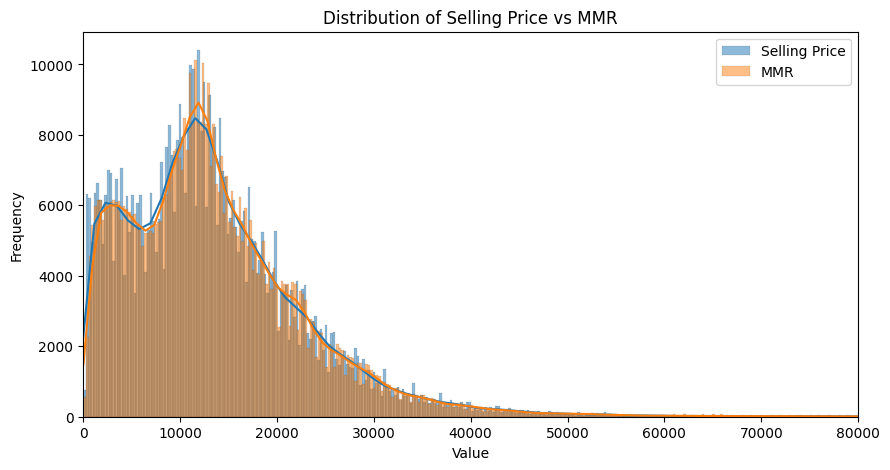

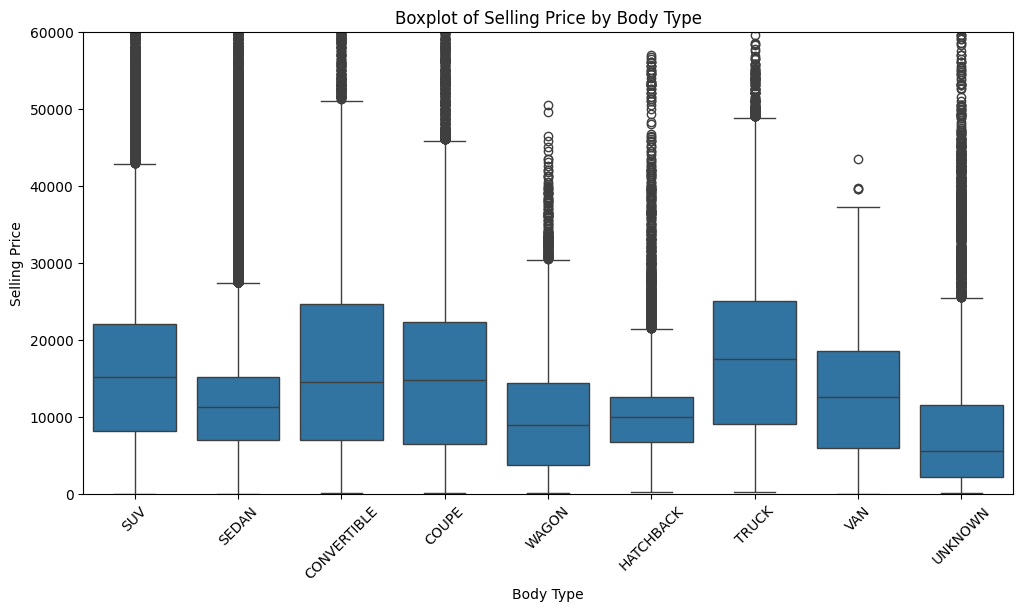

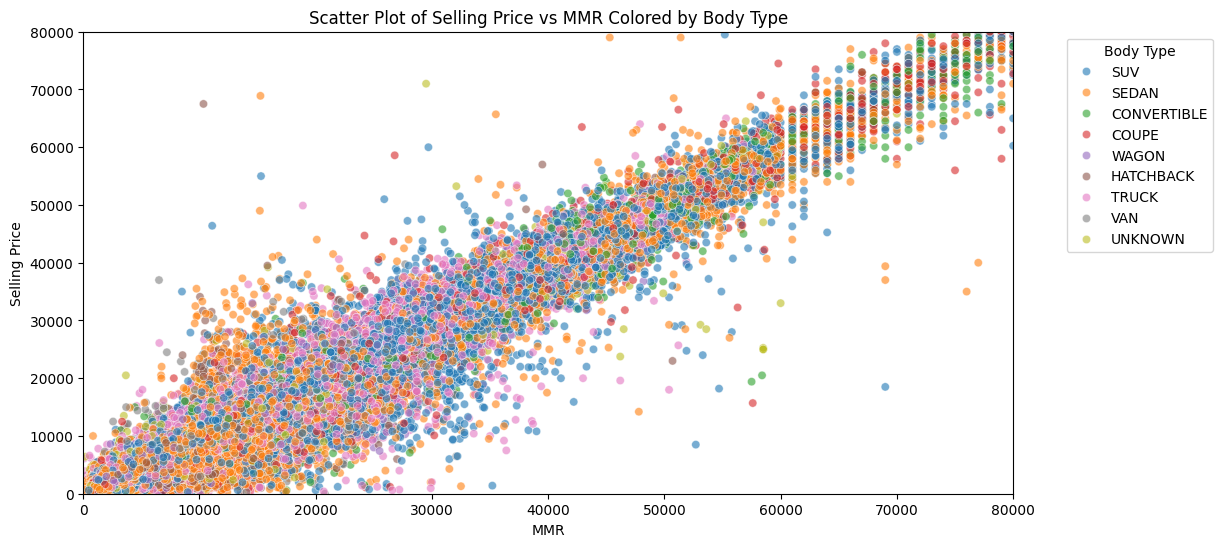

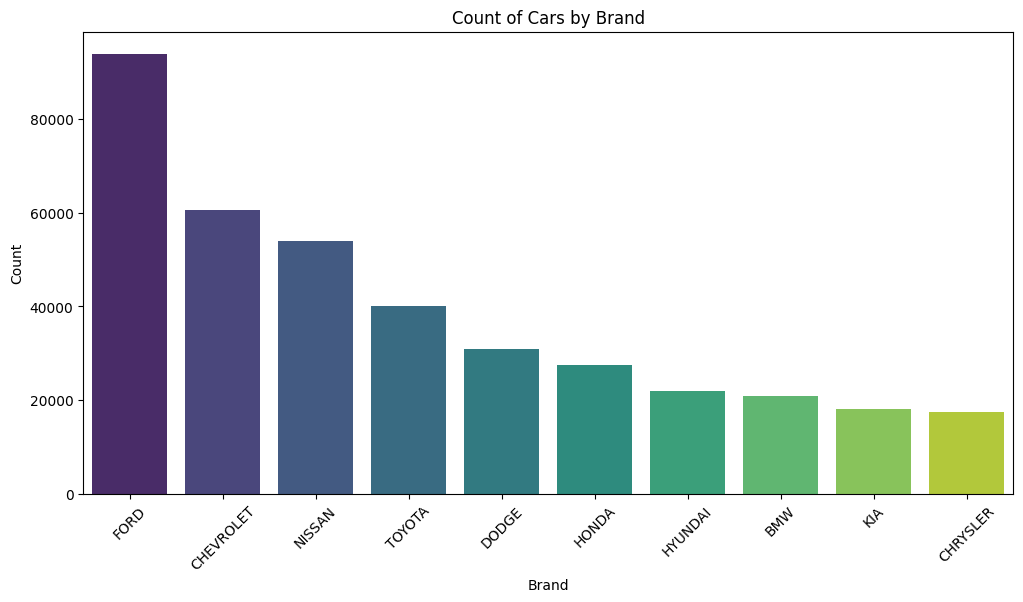

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

df_visualization = df_body_mapping.copy()
df_visualization = df_visualization.drop(columns=['vin', 'saledate', 'seller', 'color', 'interior', 'transmission'])

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df_visualization['sellingprice'], kde=True, label='Selling Price', alpha=0.5, ax=ax)
sns.histplot(df_visualization['mmr'], kde=True, label='MMR', alpha=0.5, ax=ax)

ax.set_title('Distribution of Selling Price vs MMR')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 80000)
ax.legend()
plt.show()

# Boxplot of selling price by body type
plt.figure(figsize=(12, 6))
sns.boxplot(x='body', y='sellingprice', data=df_visualization)
plt.title('Boxplot of Selling Price by Body Type')
plt.xlabel('Body Type')
plt.ylabel('Selling Price')
plt.ylim(0, 60000)
plt.xticks(rotation=45)
plt.show()

# Scatter plot of selling price vs mmr colored by body type
plt.figure(figsize=(12, 6))
sns.scatterplot(x='mmr', y='sellingprice', hue='body', data=df_visualization, alpha=0.6)
plt.title('Scatter Plot of Selling Price vs MMR Colored by Body Type')
plt.xlabel('MMR')
plt.ylabel('Selling Price')
plt.xlim(0, 80000)
plt.ylim(0, 80000)
plt.legend(title='Body Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


# Top 10 most soldf car brands
df_top10_make = df_visualization['make'].value_counts().nlargest(10).index
df_top10 = df_visualization[df_visualization['make'].isin(df_top10_make)]
plt.figure(figsize=(12, 6))
sns.countplot(x='make', data=df_top10, order=df_top10['make'].value_counts().index, palette='viridis')
plt.title('Count of Cars by Brand')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


# MLP Pipeline: Regression then Classification

In the next steps we will use the same MLP-based architecture for two tasks:

1. Regression:
    - target: `sellingprice`
    - model learns from structured attributes (`year`, `make`, `model`, `body`, `odometer`, `condition_normalized`, etc.)
    - output: continuous price estimate

2. Classification:
    - target(s): car `brand` / `model` (or other categorical labels)
    - model uses similar feature processing and convolutional layers
    - output: discrete class probabilities

This demonstrates a flexible deep learning pipeline where we first validate MLP performance on a regression objective, then adapt to classification on the same cleaned dataset.

### Encode categoricals and prepare feautures

In [6]:
import torch
import torch.nn as nn

class CarPricePredictor(nn.Module):
    def __init__(self, input_size):
        super(CarPricePredictor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)
    

from sklearn.preprocessing import LabelEncoder, MinMaxScaler

df_mlp = df_body_mapping.copy()
df_mlp = df_mlp.drop(columns=['vin', 'state', 'seller', 'model', 'trim'])
df_mlp = df_mlp.dropna()

# Encode categorical columns
cat_cols = ['make', 'body', 'transmission', 'color', 'interior']
le = LabelEncoder()
for col in cat_cols:
    df_mlp[col] = le.fit_transform(df_mlp[col].astype(str))

# Drop saledate (not useful as-is, or extract month/year if you want to keep it)
df_mlp = df_mlp.drop(columns=['saledate'])

# Features and target
X = df_mlp.drop(columns=['sellingprice']).values
y = df_mlp['sellingprice'].values.reshape(-1, 1)

# Scale
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

# Instantiate the model
model = CarPricePredictor(X.shape[1])
print(f"Model created with input size: {X.shape[1]}")
print(model)

Model created with input size: 9
CarPricePredictor(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


### Convert to tensors and create Dataloader

In [7]:
from torch.utils.data import DataLoader, TensorDataset

# Check for NaN/Inf values before creating tensors
print(f"NaN in X: {np.isnan(X).sum()}, Inf in X: {np.isinf(X).sum()}")
print(f"NaN in y: {np.isnan(y).sum()}, Inf in y: {np.isinf(y).sum()}")

X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y)

dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_data, test_data = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Training samples: {len(train_data)}, Test samples: {len(test_data)}")

NaN in X: 0, Inf in X: 0
NaN in y: 0, Inf in y: 0
Training samples: 437580, Test samples: 109396


Training Loop

In [8]:
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50
best_loss = float('inf')
patience = 5
patience_counter = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0
    batch_count = 0
    
    for X_batch, y_batch in train_loader:
        # Move data to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_loss += loss.item()
        batch_count += 1
    
    avg_loss = total_loss / batch_count
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")
    
    # Early stopping if loss plateaus
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

Using device: cpu
Epoch 5/50, Loss: 0.000107
Epoch 10/50, Loss: 0.000107
Early stopping at epoch 14 (no improvement for 5 epochs)


In [9]:
# Evaluate MRE on model
model.eval()
with torch.no_grad():
    predictions = []
    actuals = []
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        preds = model(X_batch)
        predictions.append(preds.cpu().numpy())
        actuals.append(y_batch.cpu().numpy())
    
    predictions = np.vstack(predictions)
    actuals = np.vstack(actuals)

# Inverse transform predictions and actuals
predictions = scaler_y.inverse_transform(predictions)
actuals = scaler_y.inverse_transform(actuals)
mre = np.mean(np.abs(predictions - actuals) / np.abs(actuals))
print(f"Mean Relative Error (MRE) on test set: {mre:.4f}")

# Save the trained model
torch.save(model.state_dict(), 'car_price_predictor.pth')
print("Model saved as 'car_price_predictor.pth'")


Mean Relative Error (MRE) on test set: 0.3600
Model saved as 'car_price_predictor.pth'


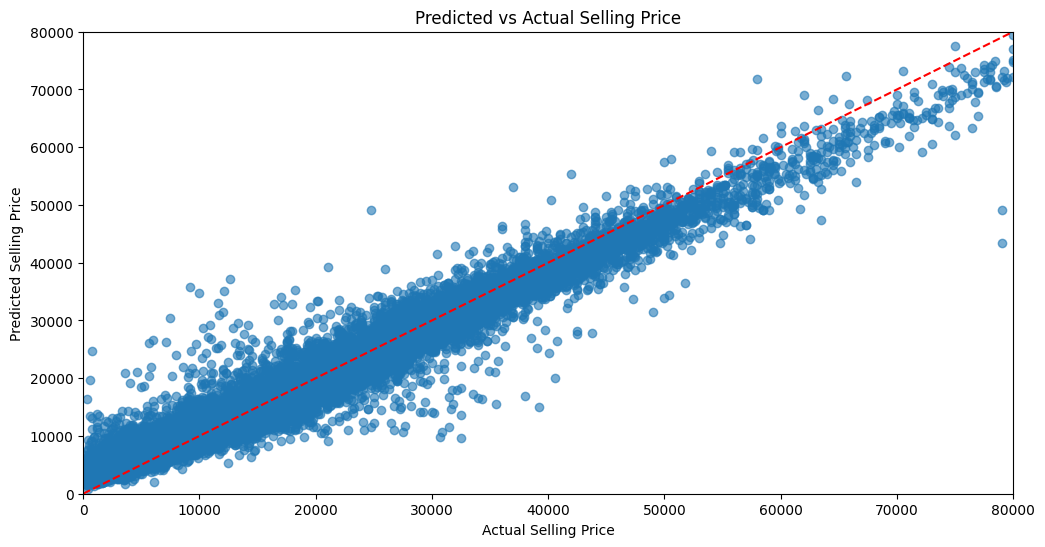

Feature weights from the first layer:
        year      make      body  transmission  odometer     color  interior  \
0  -0.126224  0.025192  0.243994      0.144607 -0.084495 -0.322170 -0.065473   
1   0.085438 -0.000206  0.015909      0.002111  0.011518  0.002506  0.007263   
2  -0.290023 -0.059589 -0.111566      0.027702  0.064344  0.075119  0.179279   
3   0.007004 -0.020674  0.020311     -0.011702 -0.168847  0.006538  0.001172   
4  -0.047278 -0.016636  0.009340     -0.001791 -0.114653 -0.013706  0.011584   
..       ...       ...       ...           ...       ...       ...       ...   
59 -0.156560 -0.106978 -0.047497     -0.142622  0.490497 -0.255258 -0.064687   
60 -0.102390 -0.085198 -0.257032     -0.044147 -0.403382 -0.101766 -0.343776   
61  0.067952 -0.025294  0.007334      0.019054  0.048420  0.005159 -0.024186   
62  0.022922  0.008463  0.000999     -0.025892  0.284725 -0.006954  0.006130   
63 -0.079549  0.025376 -0.116075     -0.348929 -0.059864  0.060282 -0.173484   

 

In [ ]:
# Visualize predictions vs actuals
plt.figure(figsize=(12, 6))
plt.scatter(actuals, predictions, alpha=0.6)
plt.plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], 'r--') 
plt.title('Predicted vs Actual Selling Price')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.xlim(0, 80000)
plt.ylim(0, 80000)
plt.show()


### Model Evaluation

In [ ]:
# Model weights analysis
input_size = X.shape[1]
weights = model.network[0].weight.data.cpu().numpy()
feature_names = df_mlp.drop(columns=['sellingprice']).columns
weight_df = pd.DataFrame(weights, columns=feature_names)
print("Feature weights from the first layer:")
print(weight_df)

# Analyze feature importance based on absolute weights
feature_importance = weight_df.abs().mean().sort_values(ascending=False)
print("\nFeature importance based on absolute weights:")
print(feature_importance)



Importance of body types based on absolute weights:
body    0.09981
dtype: float32


### Visualization of Most important features of the Model

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'mmr'),
  Text(1, 0, 'condition_normalized'),
  Text(2, 0, 'odometer'),
  Text(3, 0, 'year'),
  Text(4, 0, 'body'),
  Text(5, 0, 'color'),
  Text(6, 0, 'transmission'),
  Text(7, 0, 'interior'),
  Text(8, 0, 'make')])

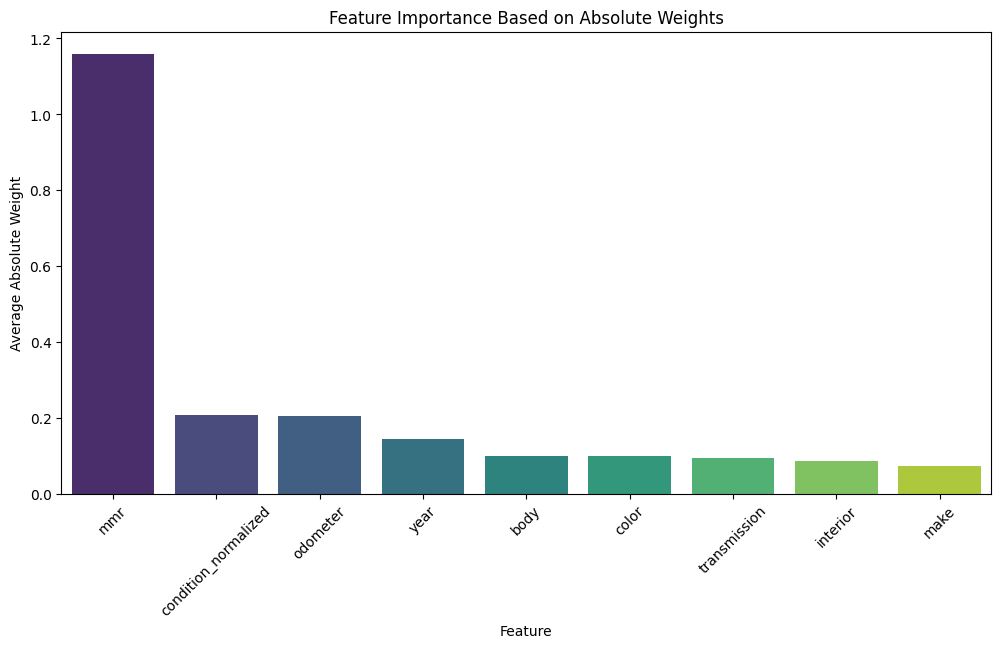

In [12]:
# Visualize feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importance.index, y=feature_importance.values, palette='viridis')
plt.title('Feature Importance Based on Absolute Weights')
plt.xlabel('Feature')
plt.ylabel('Average Absolute Weight')
plt.xticks(rotation=45)

# Conclusion
The feature importance analysis confirms that MMR is by far the most influential input (1.16), nearly six times more impactful than the next features. This is expected and validates the model's learning: MMR is a Manheim-calculated wholesale market value derived from the same vehicle attributes present in this dataset — year, make, body, odometer, condition, color, and transmission — meaning it acts as a pre-compressed price signal that the network can lean on efficiently rather than re-deriving value from scratch. Following MMR, condition (0.208) and odometer (0.206) are effectively tied as the second most important signals, capturing physical wear and mileage depreciation that MMR may not fully individualize. Year (0.145) adds temporal depreciation context, while body style (0.100), color (0.098), and transmission (0.095) contribute moderate secondary signal. Interior (0.087) and make (0.072) rank lowest — not because they are irrelevant to car buyers, but because their information is largely already captured by MMR. Overall, the weight distribution reflects a model that has correctly learned the structure of the used car market: anchor on the market benchmark, then refine with individual vehicle condition and mileage.
